# 06 - Embedding & hybrid models

This notebook tests whether ESM-2 embeddings break the handcrafted-feature ceiling (macro-F1
~0.527 from notebook 04), and whether combining both representations beats either
one alone.

**Discipline:** identical proteins, identical train/test split logic as NB04 — only
the *features* change. 


## 1. Setup & load

In [1]:
import sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EMB_DIR       = PROJECT_ROOT / "data" / "embeddings"
RESULTS_DIR   = PROJECT_ROOT / "results"
SRC_DIR       = PROJECT_ROOT / "src"
(RESULTS_DIR / "figures").mkdir(parents=True, exist_ok=True)

In [3]:
sys.path.insert(0, str(SRC_DIR))
from embeddings import load_embeddings
import features as F           # same module NB03/NB04 use
import train as T              # for RANDOM_STATE, to match NB04 exactly

CLASS_ORDER  = ["enzyme", "dna_rna_binding", "receptor", "transporter", "structural", "other"]
RANDOM_STATE = T.RANDOM_STATE
FEATURE_COLS = F.feature_columns()   # canonical 32-feature list
print(f"Handcrafted feature columns: {len(FEATURE_COLS)}")

Handcrafted feature columns: 32


## 2. Load and align the three sources

Labels + handcrafted features live together in `sequence_features.csv` (the label
column `function_class` sits alongside the features — we select features by
`FEATURE_COLS` so it never leaks into the matrix). Embeddings come from NB05.

In [6]:
# Handcrafted features + labels (indexed by accession, as in NB04)
feats = pd.read_csv(PROCESSED_DIR / "sequence_features.csv", index_col="accession")
feats.index = feats.index.astype(str)

# Embeddings + their accession order
emb, emb_meta = load_embeddings(EMB_DIR)
emb_df = pd.DataFrame(emb, index=emb_meta["accession"].astype(str))
emb_df.index.name = "accession"

print(f"features file: {feats.shape}")
print(f"embeddings:    {emb_df.shape}")


features file: (8520, 33)
embeddings:    (8513, 1280)


### Drop duplicate sequences (same logic as NB04), then take shared accessions

NB04 dedups via `labeled_dataset.csv` (keep first occurrence of each unique
sequence). We replicate that, then intersect with the embedding accessions so
every matrix shares one row order.

In [7]:
src_df = pd.read_csv(PROCESSED_DIR / "labeled_dataset.csv")
keep_acc = src_df.drop_duplicates(subset="sequence", keep="first")["accession"].astype(str)

before = len(feats)
feats = feats.loc[feats.index.intersection(keep_acc)]
print(f"Dropped {before - len(feats)} duplicate-sequence rows -> {len(feats)} unique")

Dropped 7 duplicate-sequence rows -> 8513 unique


In [8]:
# Accessions present in BOTH handcrafted features and embeddings.
shared = feats.index.intersection(emb_df.index)
order  = list(shared)                      # canonical row order
print(f"Shared with embeddings: {len(order)}")

Shared with embeddings: 8513


In [9]:
y       = feats.loc[order, "function_class"].to_numpy()
X_hand  = feats.loc[order, FEATURE_COLS].to_numpy()   # explicit cols -> no leak
X_emb   = emb_df.loc[order].to_numpy()
X_hybrid = np.hstack([X_hand, X_emb])

print(f"  handcrafted dims: {X_hand.shape[1]}")
print(f"  embedding   dims: {X_emb.shape[1]}")
print(f"  hybrid      dims: {X_hybrid.shape[1]}")
assert X_hand.dtype.kind == "f", "Handcrafted block is not all-float -- check FEATURE_COLS"

  handcrafted dims: 32
  embedding   dims: 1280
  hybrid      dims: 1312


## 3. Stratified train/test split (reused for every feature set)

In [10]:
from sklearn.model_selection import train_test_split
idx = np.arange(len(order))
train_idx, test_idx = train_test_split(
    idx, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
y_train, y_test = y[train_idx], y[test_idx]
print(f"Train: {len(train_idx)}   Test: {len(test_idx)}")


Train: 6810   Test: 1703


## 4. Models + evaluation helper (with progress output)

- **ESM + LogReg** — standardized; `max_iter` raised for 1280 dims.
- **ESM + XGBoost** and **Hybrid + XGBoost** — `tree_method="hist"` for speed on
  dense high-dim data; trees need no scaling.

The helper runs a manual 5-fold CV loop that prints each fold as it completes, then
fits the final model.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from sklearn.base import clone
from xgboost import XGBClassifier

In [12]:

le = LabelEncoder().fit(CLASS_ORDER)
print(f"Classes: {le.classes_}")

Classes: ['dna_rna_binding' 'enzyme' 'other' 'receptor' 'structural' 'transporter']


In [13]:
def make_xgb():
    return XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9, tree_method="hist",
        objective="multi:softprob", num_class=len(CLASS_ORDER),
        eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1,
    )

def make_logreg():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE),
    )

def evaluate(name, model, X, needs_int_labels):
    print(f"\n>>> {name}")
    t0 = time.time()
    Xtr, Xte = X[train_idx], X[test_idx]
    ytr = le.transform(y_train) if needs_int_labels else y_train

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = []
    for k, (tr, va) in enumerate(cv.split(Xtr, ytr), 1):
        m = clone(model)
        m.fit(Xtr[tr], ytr[tr])
        s = f1_score(ytr[va], m.predict(Xtr[va]), average="macro")
        fold_scores.append(s)
        print(f"    fold {k}/5  macro-F1={s:.4f}  ({time.time()-t0:.0f}s)")

    print("    fitting final model on full train set...")
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    pred_lbl = le.inverse_transform(pred) if needs_int_labels else pred
    true_lbl = y_test
    print(f"    done in {time.time()-t0:.0f}s")

    return {
        "feature_set": name.split(" | ")[0],
        "model": name.split(" | ")[1],
        "cv_macro_f1_mean": round(float(np.mean(fold_scores)), 4),
        "cv_macro_f1_std": round(float(np.std(fold_scores)), 4),
        "test_accuracy": round(accuracy_score(true_lbl, pred_lbl), 4),
        "test_macro_f1": round(f1_score(true_lbl, pred_lbl, average="macro"), 4),
        "test_weighted_f1": round(f1_score(true_lbl, pred_lbl, average="weighted"), 4),
    }, (true_lbl, pred_lbl)


## 5. Run the models

In [14]:
rows, preds = [], {}

r, p = evaluate("ESM (1280) | logreg",  make_logreg(), X_emb,    needs_int_labels=False)
rows.append(r); preds["ESM | logreg"] = p

r, p = evaluate("ESM (1280) | xgboost", make_xgb(),    X_emb,    needs_int_labels=True)
rows.append(r); preds["ESM | xgboost"] = p

r, p = evaluate("Hybrid (1312) | xgboost", make_xgb(), X_hybrid, needs_int_labels=True)
rows.append(r); preds["Hybrid | xgboost"] = p

new_df = pd.DataFrame(rows)
new_df



>>> ESM (1280) | logreg
    fold 1/5  macro-F1=0.6400  (8s)
    fold 2/5  macro-F1=0.6512  (18s)
    fold 3/5  macro-F1=0.6509  (25s)
    fold 4/5  macro-F1=0.6424  (34s)
    fold 5/5  macro-F1=0.6409  (40s)
    fitting final model on full train set...
    done in 50s

>>> ESM (1280) | xgboost
    fold 1/5  macro-F1=0.6946  (328s)
    fold 2/5  macro-F1=0.6598  (652s)
    fold 3/5  macro-F1=0.6982  (977s)
    fold 4/5  macro-F1=0.6690  (1306s)
    fold 5/5  macro-F1=0.6814  (1638s)
    fitting final model on full train set...
    done in 2009s

>>> Hybrid (1312) | xgboost
    fold 1/5  macro-F1=0.6863  (339s)
    fold 2/5  macro-F1=0.6600  (676s)
    fold 3/5  macro-F1=0.6944  (1016s)
    fold 4/5  macro-F1=0.6804  (1354s)
    fold 5/5  macro-F1=0.6763  (1690s)
    fitting final model on full train set...
    done in 2076s


,feature_set,model,cv_macro_f1_mean,cv_macro_f1_std,test_accuracy,test_macro_f1,test_weighted_f1
0,ESM (1280),logreg,0.6451,0.0049,0.7052,0.6754,0.7042
1,ESM (1280),xgboost,0.6806,0.0147,0.7416,0.7165,0.7401
2,Hybrid (1312),xgboost,0.6795,0.0115,0.7457,0.7223,0.7449


## 6. Combine with the baselines

In [15]:
base = pd.read_csv(RESULTS_DIR / "baseline_metrics.csv").assign(feature_set="Handcrafted (32)")
cols = ["feature_set", "model", "cv_macro_f1_mean", "cv_macro_f1_std", "test_accuracy", "test_macro_f1", "test_weighted_f1"]
base = base[[c for c in cols if c in base.columns]]
combined = pd.concat([base, new_df[cols]], ignore_index=True)
combined = combined.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
combined


,feature_set,model,cv_macro_f1_mean,cv_macro_f1_std,test_accuracy,test_macro_f1,test_weighted_f1
0,Hybrid (1312),xgboost,0.6795,0.0115,0.7457,0.7223,0.7449
1,ESM (1280),xgboost,0.6806,0.0147,0.7416,0.7165,0.7401
2,ESM (1280),logreg,0.6451,0.0049,0.7052,0.6754,0.7042
3,Handcrafted (32),xgboost,0.4803,0.0146,0.5649,0.5267,0.5541
4,Handcrafted (32),histgb,0.4759,0.0115,0.5567,0.5247,0.5488
5,Handcrafted (32),random_forest,0.4596,0.0056,0.5555,0.5091,0.5350
6,Handcrafted (32),logreg,0.3988,0.0158,0.4427,0.4197,0.4487


## 7. Comparison plot

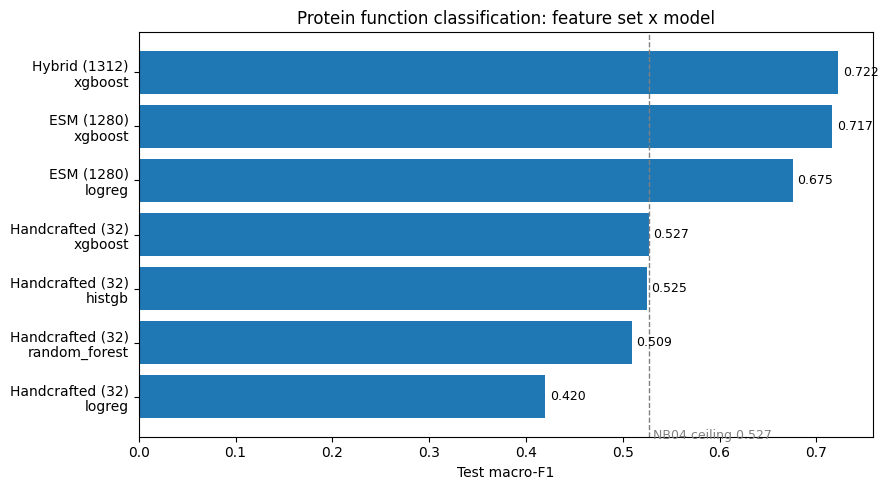

In [16]:
plot_df = combined.copy()
plot_df["label"] = plot_df["feature_set"] + "\n" + plot_df["model"].astype(str)
plot_df = plot_df.sort_values("test_macro_f1")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(plot_df["label"], plot_df["test_macro_f1"])
ax.axvline(0.527, ls="--", lw=1, color="grey")
ax.text(0.527, -0.6, " NB04 ceiling 0.527", color="grey", fontsize=9, va="top")
ax.set_xlabel("Test macro-F1")
ax.set_title("Protein function classification: feature set x model")
for b, v in zip(bars, plot_df["test_macro_f1"]):
    ax.text(v + 0.005, b.get_y()+b.get_height()/2, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "figures" / "model_comparison_barplot.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Report + confusion matrix for the best NEW model

Best: Hybrid (1312) | xgboost  (test macro-F1 0.7223)

                 precision    recall  f1-score   support

         enzyme       0.81      0.87      0.84       537
dna_rna_binding       0.76      0.78      0.77       345
       receptor       0.89      0.73      0.80       151
    transporter       0.75      0.72      0.74       260
     structural       0.77      0.52      0.62       149
          other       0.53      0.59      0.56       261

       accuracy                           0.75      1703
      macro avg       0.75      0.70      0.72      1703
   weighted avg       0.75      0.75      0.74      1703



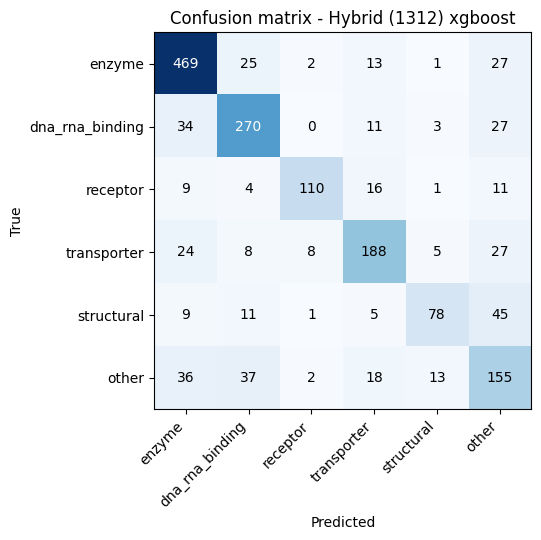

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
key_lookup = {
    ("ESM (1280)", "logreg"): "ESM | logreg",
    ("ESM (1280)", "xgboost"): "ESM | xgboost",
    ("Hybrid (1312)", "xgboost"): "Hybrid | xgboost",
}
top = combined.iloc[0]
pred_key = key_lookup.get((top["feature_set"], top["model"]))
if pred_key:
    true_lbl, pred_lbl = preds[pred_key]
    print(f"Best: {top['feature_set']} | {top['model']}  (test macro-F1 {top['test_macro_f1']})\n")
    print(classification_report(true_lbl, pred_lbl, labels=CLASS_ORDER,
                                target_names=CLASS_ORDER, zero_division=0))
    cm = confusion_matrix(true_lbl, pred_lbl, labels=CLASS_ORDER)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(CLASS_ORDER))); ax.set_xticklabels(CLASS_ORDER, rotation=45, ha="right")
    ax.set_yticks(range(len(CLASS_ORDER))); ax.set_yticklabels(CLASS_ORDER)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Confusion matrix - {top['feature_set']} {top['model']}")
    for i in range(len(CLASS_ORDER)):
        for j in range(len(CLASS_ORDER)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black")
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / "figures" / "confusion_matrix_best.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Best model is the baseline; see NB04 for its report.")


## 9. Save the combined comparison

In [19]:
out_path = RESULTS_DIR / "model_comparison.csv"
combined.to_csv(out_path, index=False)
print(f"Saved -> {out_path}")
combined


Saved -> C:\Users\sridi\Documents\Learning\protein-function-active-learning\results\model_comparison.csv


,feature_set,model,cv_macro_f1_mean,cv_macro_f1_std,test_accuracy,test_macro_f1,test_weighted_f1
0,Hybrid (1312),xgboost,0.6795,0.0115,0.7457,0.7223,0.7449
1,ESM (1280),xgboost,0.6806,0.0147,0.7416,0.7165,0.7401
2,ESM (1280),logreg,0.6451,0.0049,0.7052,0.6754,0.7042
3,Handcrafted (32),xgboost,0.4803,0.0146,0.5649,0.5267,0.5541
4,Handcrafted (32),histgb,0.4759,0.0115,0.5567,0.5247,0.5488
5,Handcrafted (32),random_forest,0.4596,0.0056,0.5555,0.5091,0.5350
6,Handcrafted (32),logreg,0.3988,0.0158,0.4427,0.4197,0.4487


## 10. Interpretation

- **Did ESM break the 0.527 ceiling?** Decisively. ESM/XGBoost reached test macro-F1 0.717 versus the best handcrafted model's 0.527 — a ~0.19 absolute gain. This confirms the diagnosis that the bottleneck was the representation, not the classifier. The 32 handcrafted features captured coarse biochemistry, but ESM-2 embeddings encode contextual sequence patterns (motifs, domain-like signals) that the handcrafted set could not.
- **Linear vs non-linear on embeddings:** ESM/LogReg alone reached 0.675 — already well above every handcrafted model, including handcrafted/XGBoost. That a linear model on embeddings beats a boosted-tree model on handcrafted features is the sharpest single piece of evidence here: ESM places the classes in a much more linearly separable space. XGBoost on embeddings (0.717) adds a further ~0.04, suggesting some residual non-linear structure remains to exploit.
- **Does hybrid help?** Only marginally. Hybrid/XGBoost (0.722) beats ESM/XGBoost (0.717) by ~0.006 on test macro-F1, and on the cross-validation mean the two are effectively tied (0.6795 vs 0.6806, within one standard deviation of each other). This is consistent with the embeddings already capturing most of what the handcrafted biochemistry encodes; the 32 extra features add little independent signal. This is a finding, not a disappointment — it tells us the representation is near-saturated for this label set.  
- **Per-class:** `enzyme` and `dna_rna_binding` are strongest (469 and 270 correct on the diagonal). The persistent difficulty is `structural` and `other`: 45 true structural proteins were predicted other, and other is broadly diffuse — unsurprising, since other is a catch-all without a coherent biochemical signature, and structural overlaps with it. `receptor`, the weakest class in NB04, is now reasonably recovered (110 correct), one of ESM's clearest rescues. The main remaining confusions — `structural`↔`other`, and a steady leak of several classes into `other` — point to label-definition fuzziness rather than representation weakness (labels were derived from keywords/GO/EC, some of the `other` confusion reflects genuine ambiguity in the label cascade, not model error.).


## 11. Statistical significance: McNemar's test
Compares two classifiers on the SAME test set by examining their per-protein disagreements (not their headline scores). Preferred over comparing F1 values directly because both models saw the identical proteins.

In [21]:
from statsmodels.stats.contingency_tables import mcnemar

In [22]:
# Refitting the handcrafted/XGBoost baseline on THIS split so we can compare it ---
# Uses the same FEATURE_COLS handcrafted block.
hand_model = make_xgb()
hand_model.fit(X_hand[train_idx], le.transform(y_train))
hand_pred = le.inverse_transform(hand_model.predict(X_hand[test_idx]))
preds["Handcrafted | xgboost"] = (y_test, hand_pred)
print("Refit handcrafted/XGBoost on current split and stored its predictions.")

Refit handcrafted/XGBoost on current split and stored its predictions.


In [23]:

def mcnemar_compare(name_a, name_b):
    true_a, pred_a = preds[name_a]
    true_b, pred_b = preds[name_b]
    # Both evaluated on the same test set in the same order.
    assert list(true_a) == list(true_b), "Test sets differ -- cannot pair"

    correct_a = (np.asarray(pred_a) == np.asarray(true_a))
    correct_b = (np.asarray(pred_b) == np.asarray(true_b))

    a_right_b_wrong = int((correct_a & ~correct_b).sum())
    b_right_a_wrong = int((~correct_a & correct_b).sum())

    table = [[0, a_right_b_wrong],
             [b_right_a_wrong, 0]]
    # exact=True when discordant counts are small (<25); else chi-square with
    # continuity correction. We pick automatically.
    n_disc = a_right_b_wrong + b_right_a_wrong
    use_exact = n_disc < 25
    result = mcnemar(table, exact=use_exact, correction=not use_exact)

    print(f"\n{name_a}  vs  {name_b}")
    print(f"  {name_a} right / {name_b} wrong: {a_right_b_wrong}")
    print(f"  {name_b} right / {name_a} wrong: {b_right_a_wrong}")
    stat_label = "exact" if use_exact else "chi-squared"
    print(f"  {stat_label} statistic = {result.statistic:.3f}   p-value = {result.pvalue:.4g}")
    verdict = "SIGNIFICANT difference" if result.pvalue < 0.05 else "NOT significant (treat as tied)"
    print(f"  -> {verdict} at alpha=0.05")


In [24]:
# The three comparisons that matter:
mcnemar_compare("Handcrafted | xgboost", "ESM | xgboost")   # headline: expect SIGNIFICANT
mcnemar_compare("ESM | xgboost",         "Hybrid | xgboost")# expect NOT significant
mcnemar_compare("ESM | logreg",          "ESM | xgboost")   # linear vs non-linear on ESM


Handcrafted | xgboost  vs  ESM | xgboost
  Handcrafted | xgboost right / ESM | xgboost wrong: 67
  ESM | xgboost right / Handcrafted | xgboost wrong: 359
  chi-squared statistic = 198.782   p-value = 3.852e-45
  -> SIGNIFICANT difference at alpha=0.05

ESM | xgboost  vs  Hybrid | xgboost
  ESM | xgboost right / Hybrid | xgboost wrong: 37
  Hybrid | xgboost right / ESM | xgboost wrong: 44
  chi-squared statistic = 0.444   p-value = 0.505
  -> NOT significant (treat as tied) at alpha=0.05

ESM | logreg  vs  ESM | xgboost
  ESM | logreg right / ESM | xgboost wrong: 116
  ESM | xgboost right / ESM | logreg wrong: 178
  chi-squared statistic = 12.656   p-value = 0.0003743
  -> SIGNIFICANT difference at alpha=0.05
